In [1]:
import pandas as pd
import numpy as np
import os
import pytz

from EDW_data import *

import pickle
import datetime as dt
import math
import matplotlib.pyplot as plt
import matplotlib.dates as md
import datetime as dt
from datetime import datetime
from datetime import timedelta
from matplotlib.dates import DateFormatter

from DateTime_DateNum_Conversion  import DateTime_to_DateNum,DateNum_to_DateTime
from dropTimeZone_forPlotly import dropTimeZone, AddNaNs
import h5py 

import plotly
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot
import plotly.io as pio
from plotly import tools

In [2]:
### init directories, get metadata

In [3]:
StudyDir = '//mad3/MGH-NEURO-CDAC/Projects/ICU_SLEEP_STUDY/data/data_analysis/Study/'
datatable = pd.read_csv(os.path.join(StudyDir, 'ICUSleep_DataTable_ICUonly.csv'))
# EDW pickle:
patient_object_fname = 'patient_objects.pickle'
studyID = 2

In [4]:
datatable.head()

,StudyID,ADT_TransferIn,ADT_TransferOut,CAM_Date,BMFileConverted,BMDataAllGood,BMFileID,BMFileNotes,AirGoDone,AirGoFileNotes,EventName,ICU_Site,ICU_Bed,MRN,CAM_performed,ADT_Admission,ADT_Discharge,ADT_Bed
0,1.0,2018-06-05 07:16:00,2018-06-08 14:45:00,2018-06-06 16:51:00,1.0,NaN,BLK07_768-1528197453,NaN,NaN,NaN,"ICU Day 1, pm",Blake 7,68,1298742.0,Yes,2018-06-04 21:13:00,2018-06-10 14:01:00,B0768 A
1,1.0,2018-06-05 07:16:00,2018-06-08 14:45:00,2018-06-07 10:30:00,1.0,NaN,BLK07_768-1528197453,NaN,NaN,NaN,"ICU Day 2, am",Blake 7,68,1298742.0,Yes,2018-06-04 21:13:00,2018-06-10 14:01:00,B0768 A
2,1.0,2018-06-05 07:16:00,2018-06-08 14:45:00,2018-06-07 17:30:00,1.0,NaN,BLK07_768-1528197453,NaN,NaN,NaN,"ICU Day 2, pm",Blake 7,68,1298742.0,Yes,2018-06-04 21:13:00,2018-06-10 14:01:00,B0768 A
3,1.0,2018-06-05 07:16:00,2018-06-08 14:45:00,2018-06-08 11:07:00,1.0,NaN,BLK07_768-1528197453,NaN,NaN,NaN,"ICU Day 3, am",Blake 7,68,1298742.0,Yes,2018-06-04 21:13:00,2018-06-10 14:01:00,B0768 A
4,2.0,2018-06-11 14:27:00,2018-06-12 22:07:00,2018-06-11 20:14:00,1.0,NaN,ELL04_432-1528528595,NaN,NaN,NaN,"ICU Day 1, pm",Ellison 4,32,6378271.0,Yes,2018-06-09 02:03:00,2018-06-18 13:49:00,E0432 A


In [69]:
fileIDs_subject = np.unique(datatable[datatable.StudyID==studyID].BMFileID)
fileIDs_subject

array(['ELL04_432-1528528595'], dtype=object)

In [70]:
fileIDsel = fileIDs_subject[0]
fileIDsel

'ELL04_432-1528528595'

In [71]:
### load edw data

In [72]:
# open the pickle
with open(patient_object_fname, "rb") as f:
    patient_object_list = pickle.load(f)

In [73]:
id_list = [patient_object_list[x].ID for x in range(len(patient_object_list))]

In [74]:
ididx = id_list.index(str(studyID).zfill(3))

Text(0.5, 1.0, 'subject 002, BP')

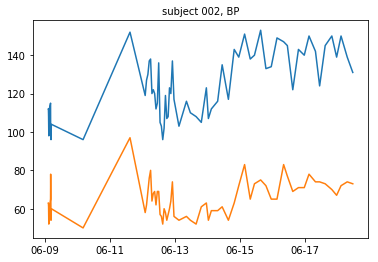

In [80]:
edw_subject = patient_object_list[ididx]

fig, ax = plt.subplots()
plt.plot(edw_subject.datenums_BP, edw_subject.systolic)
plt.plot(edw_subject.datenums_BP, edw_subject.diastolic)

ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
ax.set_title('subject ' + edw_subject.ID + ', BP', fontdict={'fontsize': 10, 'fontweight': 'medium'})

In [62]:
### load bedmaster data

In [2]:
bm_dir ='//eris1fs2/CDAC/bedmaster_data/batching/'
bm_dir = 'C:/Users/wg984/Wolfgang/BedmasterDevelopment/'

In [3]:
# bm_dir = os.path.join(bm_dir, edw_subject.ID)

In [4]:
### simple plotly or matplotlib plot.

In [5]:
fileID = 'BLK07_770-1534053914_1'

In [6]:
h5path = os.path.join(bm_dir, fileID + '.h5')
h5path

'C:/Users/wg984/Wolfgang/BedmasterDevelopment/BLK07_770-1534053914_1.h5'

In [7]:
ff = h5py.File(h5path, 'r')

In [8]:
ff.keys()

<KeysViewHDF5 ['ART1', 'ART1D', 'ART1D_dt', 'ART1M', 'ART1M_dt', 'ART1R', 'ART1R_dt', 'ART1S', 'ART1S_dt', 'ART1_dt', 'FLWR', 'FLWR_dt', 'FLWTRIG', 'FLWTRIG_dt', 'HR', 'HR_dt', 'I', 'I:E', 'I:E_dt', 'II', 'II_dt', 'INSPTM', 'INSPTM_dt', 'IN_HLD', 'IN_HLD_dt', 'I_dt', 'MAWP', 'MAWP_dt', 'MV', 'MV_dt', 'PEEP', 'PEEP_dt', 'PIP', 'PIP_dt', 'PPLAT', 'PPLAT_dt', 'PRSSUP', 'PRSSUP_dt', 'PTRR', 'PTRR_dt', 'PVC', 'PVC_dt', 'SENS', 'SENS_dt', 'SETFIO2', 'SETFIO2_dt', 'SETIE', 'SETIE_dt', 'SETPCP', 'SETPCP_dt', 'SETTV', 'SETTV_dt', 'SPO2%', 'SPO2%_dt', 'SPO2R', 'SPO2R_dt', 'SPONTMV', 'SPONTMV_dt', 'STAVF', 'STAVF_dt', 'STAVL', 'STAVL_dt', 'STAVR', 'STAVR_dt', 'STI', 'STII', 'STIII', 'STIII_dt', 'STII_dt', 'STI_dt', 'STV', 'STV_dt', 'TV', 'TV_dt', 'Vent Rate', 'Vent Rate_dt']>

In [9]:
# python list comprehension. this should be able to be done more efficient.
def unixToDateTime(unix_array):
    datetime_array = [datetime.fromtimestamp(unixT, pytz.timezone('America/New_York')).replace(tzinfo=None) for unixT in unix_array]
    return datetime_array

In [10]:
HR = ff['HR'][:]
HR_dt = ff['HR_dt'][:]

In [11]:
HR.shape

(30031, 1)

In [12]:
HR_dt.shape

(30031, 1)

In [15]:
for x in range(5):
    print('%.2f'%HR_dt[x])

1534053916.00
1534053918.00
1534053920.00
1534053922.00
1534053924.00


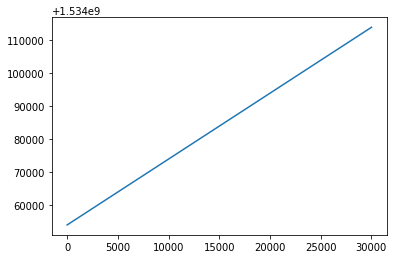

In [18]:
plt.plot(HR_dt)

In [19]:
HR_dt_datetime = unixToDateTime(HR_dt)

In [21]:
HR_dt_datetime[:5]

[datetime.datetime(2018, 8, 12, 2, 5, 16),
 datetime.datetime(2018, 8, 12, 2, 5, 18),
 datetime.datetime(2018, 8, 12, 2, 5, 20),
 datetime.datetime(2018, 8, 12, 2, 5, 22),
 datetime.datetime(2018, 8, 12, 2, 5, 24)]

In [36]:
HR = np.array(HR)
HR_dt_datetime = np.array(HR_dt_datetime)

In [37]:
subplots = tools.make_subplots(rows=1, cols=1, shared_xaxes=True, print_grid = False) 
fig = go.FigureWidget(subplots)

trace = go.Scattergl(x=HR_dt_datetime, y=HR[:,0], name = 'HR', hoverinfo = 'x+y', opacity = 0.8, mode='lines')	# , line = dict(color = '#17BECF')
fig.add_trace(trace, 1, 1 );



In [38]:
plot(fig, auto_open=True)

'file://C:\\Users\\wg984\\Wolfgang\\repos\\ICU-Sleep\\temp-plot.html'